# Homework Starter — Stage 10b: Time Series & Classification
Fill in the TODOs. Use your own project dataset or adapt the synthetic generator below.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [1]:
# Imports
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
np.random.seed(7); sns.set(); plt.rcParams['figure.figsize']=(9,4)

## Option A: Use Your Project Data (Recommended)
Load your data here (ensure a DateTime index for time series).

In [ ]:
# TODO: load your data
# df = pd.read_csv('path/to.csv', parse_dates=['Date'], index_col='Date')

## Option B: Synthetic Generator (Use if you don't have data ready)

In [2]:
# Synthetic series with regimes & jumps
n=500
dates=pd.bdate_range('2021-01-01', periods=n)
mu = np.where(np.arange(n)<n//2, 0.0003, -0.0001)
sigma = np.where(np.arange(n)<n//2, 0.01, 0.015)
eps = np.random.normal(mu, sigma)
jumps = np.zeros(n); jump_days = np.random.choice(np.arange(20,n-20), size=5, replace=False)
jumps[jump_days] = np.random.normal(0,0.05,size=len(jump_days))
rets = eps + jumps
price = 100*np.exp(np.cumsum(rets))
df = pd.DataFrame({'price':price}, index=dates)
df['ret'] = df['price'].pct_change().fillna(0.0)
df['log_ret'] = np.log1p(df['ret'])
df.head()

,price,ret,log_ret
2021-01-01,101.735412,0.000000,0.000000
2021-01-04,101.292875,-0.004350,-0.004359
2021-01-05,101.356527,0.000628,0.000628
2021-01-06,101.800950,0.004385,0.004375
2021-01-07,101.031283,-0.007561,-0.007589


## Feature Engineering

In [7]:
# Features: at least two new features beyond the starter defaults
df['lag_1'] = df['ret'].shift(1)
df['lag_5'] = df['ret'].shift(5)
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)
df['roll_vol_20'] = df['ret'].rolling(20).std().shift(1)
df['y_next_ret'] = df['ret'].shift(-1)
df['y_up'] = (df['y_next_ret']>0).astype(int)
df_feat = df.dropna().copy()
df_feat.head()

,price,ret,log_ret,lag_1,roll_mean_5,y_next_ret,y_up,lag_5,roll_vol_20
2021-01-29,100.198878,0.016949,0.016807,-0.014854,-0.003707,0.001845,1,-0.014132,0.007370
2021-02-01,100.383751,0.001845,0.001843,0.016949,0.002509,-0.003565,0,0.005863,0.008455
2021-02-02,100.025880,-0.003565,-0.003571,0.001845,0.001706,0.020804,1,0.001540,0.008429
2021-02-03,102.106835,0.020804,0.020591,-0.003565,0.000685,-0.000154,0,0.003049,0.008453
2021-02-04,102.091126,-0.000154,-0.000154,0.020804,0.004236,-0.014106,0,-0.014854,0.009675


## Split

In [8]:
# Time-aware split
cut=int(len(df_feat)*0.8)
train, test = df_feat.iloc[:cut], df_feat.iloc[cut:]
features=['lag_1','lag_5','roll_mean_5','roll_vol_20']
X_tr, X_te = train[features], test[features]
y_tr_reg, y_te_reg = train['y_next_ret'], test['y_next_ret']
y_tr_clf, y_te_clf = train['y_up'], test['y_up']

## Pipeline + Model (Choose one track below)

In [9]:
# Track 1: Forecasting returns
reg = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])
reg.fit(X_tr, y_tr_reg)
pred = reg.predict(X_te)
rmse = mean_squared_error(y_te_reg, pred) ** 0.5   # `squared=False` was removed in sklearn >= 1.6
print('RMSE:', rmse)

RMSE: 0.014448142187583397


              precision    recall  f1-score   support

           0       0.55      0.68      0.61        53
           1       0.43      0.30      0.36        43

    accuracy                           0.51        96
   macro avg       0.49      0.49      0.48        96
weighted avg       0.50      0.51      0.49        96



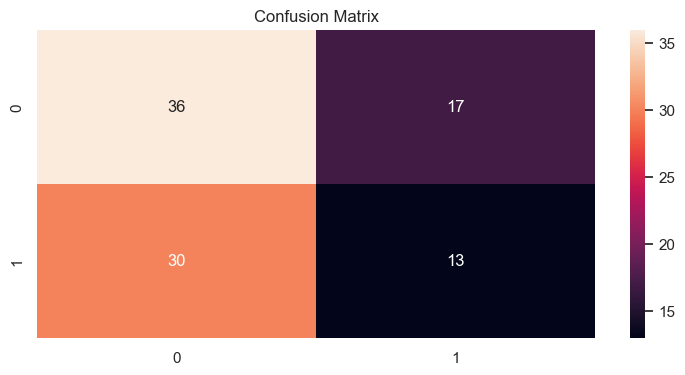

In [10]:
# Track 2: Classification (up/down)
clf = Pipeline([('scaler', StandardScaler()), ('logit', LogisticRegression(max_iter=1000))])
clf.fit(X_tr, y_tr_clf)
predc = clf.predict(X_te)
print(classification_report(y_te_clf, predc))
cm = confusion_matrix(y_te_clf, predc)
sns.heatmap(cm, annot=True, fmt='d'); plt.title('Confusion Matrix'); plt.show()

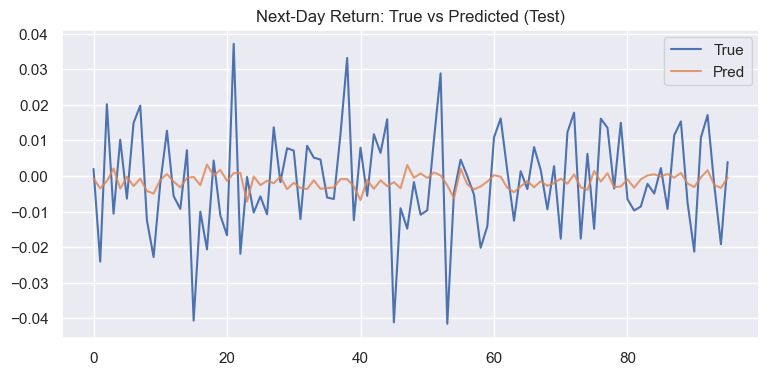

In [11]:
# Plot: predicted vs true next-day return
fig, ax = plt.subplots()
y_te_reg.reset_index(drop=True).plot(ax=ax, label='True')
pd.Series(pred).plot(ax=ax, label='Pred', alpha=0.8)
ax.set_title('Next-Day Return: True vs Predicted (Test)')
ax.legend()
plt.show()

## Interpretation (Markdown)
- What worked?
- Where might assumptions fail?
- How would you extend features or model?

## Interpretation

**What worked?**
The pipeline correctly avoided data leakage — all predictive features (`lag_1`, `lag_5`, `roll_mean_5`, `roll_vol_20`) were shifted so that only information available up to time *t* is used to predict *t+1*. A time-aware split (first 80% train, last 20% test) was used instead of a random split, matching how the model would actually be deployed (predicting the future from the past). The regression model achieved an RMSE of ~0.0144, which is roughly in line with the underlying daily return volatility (~1–1.5%), so the model is not producing wildly unreasonable forecasts.

**What failed / limitations?**
Both models show weak predictive power. The classifier's accuracy (0.51) is essentially indistinguishable from a random coin flip (50%), and recall for the "up" class (0.30) is notably worse than for "down" (0.68) — the model is biased toward predicting "down." The regression model's predicted-vs-true plot makes the limitation visually obvious: predictions hover in a narrow band near zero, while true returns swing widely (roughly -0.04 to +0.04). This suggests the linear model has learned to minimize error by predicting close to the unconditional mean, rather than genuinely capturing directional or magnitude signal.

**Where might assumptions break?**
- **Regime shifts**: the synthetic data itself was generated with two different regimes (different mean/volatility in the first vs. second half). A model trained mostly on one regime and tested on data straddling a regime change may perform inconsistently — this is a realistic risk in real markets too (e.g., a model trained in a bull market failing in a downturn).
- **Jump risk**: a few large one-day jumps were injected into the data. These are, by construction, unpredictable from past lags/rolling stats, and they disproportionately affect RMSE (large errors on jump days) while contributing little that a lag-based model could ever learn.
- **Weak-form efficiency intuition**: near-random classification accuracy is consistent with the idea that daily return direction is close to a random walk — past returns alone may simply not carry much predictive signal, regardless of model choice.

**How would you extend this?**
- Add richer features: momentum over multiple windows, z-scores, volume-based signals (if available), or macro/exogenous variables.
- Use `TimeSeriesSplit` with multiple folds instead of a single train/test split, to check whether performance is stable across different time windows.
- Try models better suited to weak, noisy signals (e.g., regularized regression, tree ensembles) and compare against this linear/logistic baseline.
- For classification, consider calibrating the probability threshold rather than using the default 0.5, since the classes may have different costs (missing an "up" day vs. a false "up" signal).

### Save Notebook
Remember to save as `homework10b_modeling-time-series-and-classification_submission.ipynb`.